In [10]:
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_, spectral_norm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import random
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
import sys
sys.path.append("../EDAF-Group_6-PV_Forecasting")

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [14]:
pv_data = pd.read_csv("../data/PV_2022_hourly.csv")
weather_data = pd.read_csv("../data/Weather_clean_NEMS.csv")

In [15]:
df_pv = pd.DataFrame(pv_data)
df_weather = pd.DataFrame(weather_data)

In [16]:
df_pv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8758 entries, 0 to 8757
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TimestampInUtc  8758 non-null   object 
 1   pv              8758 non-null   float64
dtypes: float64(1), object(1)
memory usage: 137.0+ KB


In [17]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    8760 non-null   object 
 1   Temperature                  8760 non-null   float64
 2   Sunshine Duration            8760 non-null   float64
 3   Shortwave Radiation          8760 non-null   float64
 4   Direct Shortwave Radiation   8760 non-null   float64
 5   Diffuse Shortwave Radiation  8760 non-null   float64
 6   Snowfall Amount              8760 non-null   float64
 7   Relative Humidity            8760 non-null   float64
 8   Cloud Cover Total            8760 non-null   float64
dtypes: float64(8), object(1)
memory usage: 616.1+ KB


In [18]:
df_pv.head()

,TimestampInUtc,pv
0,2022-01-01 00:00:00,0.0
1,2022-01-01 01:00:00,0.0
2,2022-01-01 02:00:00,0.0
3,2022-01-01 03:00:00,0.0
4,2022-01-01 04:00:00,0.0


In [19]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [20]:
df_pv.shape

(8758, 2)

In [21]:
df_weather.shape

(8760, 9)

In [22]:
df_pv[-10:]

,TimestampInUtc,pv
8748,2022-12-31 12:00:00,50.272210
8749,2022-12-31 13:00:00,31.335803
8750,2022-12-31 14:00:00,6.479349
8751,2022-12-31 15:00:00,0.000000
8752,2022-12-31 16:00:00,0.000000
8753,2022-12-31 17:00:00,0.000000
8754,2022-12-31 18:00:00,0.000000
8755,2022-12-31 19:00:00,0.000000
8756,2022-12-31 20:00:00,0.000000
8757,2022-12-31 21:00:00,0.000000


In [23]:
df_pv["TimestampInUtc"] = pd.to_datetime(df_pv["TimestampInUtc"])

last_time = df_pv["TimestampInUtc"].iloc[-1]

new_rows = pd.DataFrame({
    "TimestampInUtc": [
        last_time + pd.Timedelta(hours=1),
        last_time + pd.Timedelta(hours=2)
    ],
    "pv": [0, 0]
})

df_pv = pd.concat([df_pv, new_rows], ignore_index=True)

In [24]:
df_pv[-10:]

,TimestampInUtc,pv
8750,2022-12-31 14:00:00,6.479349
8751,2022-12-31 15:00:00,0.000000
8752,2022-12-31 16:00:00,0.000000
8753,2022-12-31 17:00:00,0.000000
8754,2022-12-31 18:00:00,0.000000
8755,2022-12-31 19:00:00,0.000000
8756,2022-12-31 20:00:00,0.000000
8757,2022-12-31 21:00:00,0.000000
8758,2022-12-31 22:00:00,0.000000
8759,2022-12-31 23:00:00,0.000000


In [25]:
df_pv.shape

(8760, 2)

In [26]:
df_weather.shape

(8760, 9)

In [27]:
df_merged = pd.concat([df_pv, df_weather], axis=1)

In [28]:
df_merged.head()

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,0.0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,0.0,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,0.0,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,0.0,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,0.0,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [29]:
df_merged.iloc[-10:]

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
8750,2022-12-31 14:00:00,6.479349,2022-12-31 14:00:00,15.597270,40.851063,307.05000,175.559000,131.490980,0.0,64.0,30.000002
8751,2022-12-31 15:00:00,0.000000,2022-12-31 15:00:00,14.687269,40.851063,246.53000,138.154100,108.375900,0.0,64.0,30.000002
8752,2022-12-31 16:00:00,0.000000,2022-12-31 16:00:00,13.027269,47.744680,147.73999,80.121185,67.618805,0.0,68.0,19.200000
8753,2022-12-31 17:00:00,0.000000,2022-12-31 17:00:00,11.937269,33.407090,32.04000,16.751293,15.288709,0.0,68.0,30.000002
8754,2022-12-31 18:00:00,0.000000,2022-12-31 18:00:00,12.117270,0.000000,0.00000,0.000000,0.000000,0.0,61.0,18.600000
8755,2022-12-31 19:00:00,0.000000,2022-12-31 19:00:00,11.847270,0.000000,0.00000,0.000000,0.000000,0.0,59.0,100.000000
8756,2022-12-31 20:00:00,0.000000,2022-12-31 20:00:00,11.437269,0.000000,0.00000,0.000000,0.000000,0.0,58.0,95.000000
8757,2022-12-31 21:00:00,0.000000,2022-12-31 21:00:00,10.897269,0.000000,0.00000,0.000000,0.000000,0.0,58.0,20.000000
8758,2022-12-31 22:00:00,0.000000,2022-12-31 22:00:00,10.407269,0.000000,0.00000,0.000000,0.000000,0.0,59.0,10.000000
8759,2022-12-31 23:00:00,0.000000,2022-12-31 23:00:00,10.557270,0.000000,0.00000,0.000000,0.000000,0.0,58.0,26.000000


In [30]:
df_merged.shape

(8760, 11)

In [31]:
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])
df_merged["hour"] = df_merged["timestamp"].dt.hour
df_merged["day_of_year"] = df_merged["timestamp"].dt.dayofyear
df_merged["month"] = df_merged["timestamp"].dt.month

In [32]:
df_merged.columns

Index(['TimestampInUtc', 'pv', 'timestamp', 'Temperature', 'Sunshine Duration',
       'Shortwave Radiation', 'Direct Shortwave Radiation',
       'Diffuse Shortwave Radiation', 'Snowfall Amount', 'Relative Humidity',
       'Cloud Cover Total', 'hour', 'day_of_year', 'month'],
      dtype='object')

In [33]:
df_merged["hour_sin"]  = np.sin(2 * np.pi * df_merged["hour"] / 24)
df_merged["hour_cos"]  = np.cos(2 * np.pi * df_merged["hour"] / 24)

df_merged["month_sin"] = np.sin(2 * np.pi * df_merged["month"] / 12)
df_merged["month_cos"] = np.cos(2 * np.pi * df_merged["month"] / 12)

df_merged["doy_sin"] = np.sin(2 * np.pi * df_merged["day_of_year"] / 365)
df_merged["doy_cos"] = np.cos(2 * np.pi * df_merged["day_of_year"] / 365)

In [34]:
df_merged.iloc[-744:]

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,hour,day_of_year,month,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
8016,2022-12-01 00:00:00,0.0,2022-12-01 00:00:00,2.387269,0.0,0.0,0.0,0.0,0.0,90.0,100.0,0,335,12,0.000000,1.000000,-2.449294e-16,1.0,-4.937756e-01,0.869589
8017,2022-12-01 01:00:00,0.0,2022-12-01 01:00:00,2.257269,0.0,0.0,0.0,0.0,0.0,90.0,100.0,1,335,12,0.258819,0.965926,-2.449294e-16,1.0,-4.937756e-01,0.869589
8018,2022-12-01 02:00:00,0.0,2022-12-01 02:00:00,2.057269,0.0,0.0,0.0,0.0,0.0,91.0,100.0,2,335,12,0.500000,0.866025,-2.449294e-16,1.0,-4.937756e-01,0.869589
8019,2022-12-01 03:00:00,0.0,2022-12-01 03:00:00,1.737269,0.0,0.0,0.0,0.0,0.0,93.0,100.0,3,335,12,0.707107,0.707107,-2.449294e-16,1.0,-4.937756e-01,0.869589
8020,2022-12-01 04:00:00,0.0,2022-12-01 04:00:00,1.277269,0.0,0.0,0.0,0.0,0.0,94.0,100.0,4,335,12,0.866025,0.500000,-2.449294e-16,1.0,-4.937756e-01,0.869589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,0.0,2022-12-31 19:00:00,11.847270,0.0,0.0,0.0,0.0,0.0,59.0,100.0,19,365,12,-0.965926,0.258819,-2.449294e-16,1.0,6.432491e-16,1.000000
8756,2022-12-31 20:00:00,0.0,2022-12-31 20:00:00,11.437269,0.0,0.0,0.0,0.0,0.0,58.0,95.0,20,365,12,-0.866025,0.500000,-2.449294e-16,1.0,6.432491e-16,1.000000
8757,2022-12-31 21:00:00,0.0,2022-12-31 21:00:00,10.897269,0.0,0.0,0.0,0.0,0.0,58.0,20.0,21,365,12,-0.707107,0.707107,-2.449294e-16,1.0,6.432491e-16,1.000000
8758,2022-12-31 22:00:00,0.0,2022-12-31 22:00:00,10.407269,0.0,0.0,0.0,0.0,0.0,59.0,10.0,22,365,12,-0.500000,0.866025,-2.449294e-16,1.0,6.432491e-16,1.000000


In [35]:
df_merged.drop(columns=['TimestampInUtc', 'timestamp', 'hour', 'day_of_year', 'month'], inplace=True)

In [36]:
df_test = df_merged.iloc[-744:].copy()
df_train = df_merged.iloc[:-744].copy()

In [37]:
df_train.columns

Index(['pv', 'Temperature', 'Sunshine Duration', 'Shortwave Radiation',
       'Direct Shortwave Radiation', 'Diffuse Shortwave Radiation',
       'Snowfall Amount', 'Relative Humidity', 'Cloud Cover Total', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos'],
      dtype='object')

In [38]:
TARGET_COL = "pv"

CONTINUOUS_FEATURES = [
    "Temperature", "Sunshine Duration", "Shortwave Radiation",
    "Direct Shortwave Radiation", "Diffuse Shortwave Radiation",
    "Snowfall Amount", "Relative Humidity", "Cloud Cover Total"
]

CYCLIC_FEATURES = [
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "doy_sin", "doy_cos"
]

CATEGORICAL_FEATURES = []

In [39]:
def prepare_data(df_train, df_test):

    # ---------- continuous ----------
    Xc_train = df_train[CONTINUOUS_FEATURES].values
    Xc_test  = df_test[CONTINUOUS_FEATURES].values

    # ---------- cyclic ----------
    Xcy_train = df_train[CYCLIC_FEATURES].values
    Xcy_test  = df_test[CYCLIC_FEATURES].values

    # ---------- target ----------
    y_train = df_train[[TARGET_COL]].values
    y_test  = df_test[[TARGET_COL]].values

    y_train_unscaled = y_train.copy()

    # ---------- scalers ----------
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    # fit on train
    Xc_train_scaled = scaler_X.fit_transform(Xc_train)
    Xc_test_scaled  = scaler_X.transform(Xc_test)

    y_train_scaled = scaler_y.fit_transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)

    # ---------- combine ----------
    X_train = np.concatenate([Xc_train_scaled, Xcy_train], axis=1).astype(np.float32)
    X_test  = np.concatenate([Xc_test_scaled,  Xcy_test],  axis=1).astype(np.float32)

    y_train = y_train_scaled.astype(np.float32)
    y_test  = y_test_scaled.astype(np.float32)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "y_train_unscaled": y_train_unscaled
    }

In [40]:
data = prepare_data(df_train, df_test)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

In [41]:
LOOKBACK = 168   # 7 days (tune: 24, 48, 72, 168)
HORIZON  = 24

In [42]:
def create_sequences_multistep(X, y, lookback, horizon=24):
    Xs, ys = [], []
    last_i = len(X) - lookback - horizon + 1
    for i in range(last_i):
        Xs.append(X[i:i+lookback])                     # (lookback, n_features)
        ys.append(y[i+lookback:i+lookback+horizon])    # (horizon,)
    return np.array(Xs), np.array(ys)

In [43]:
X_train_seq, y_train_seq = create_sequences_multistep(X_train, y_train, LOOKBACK, HORIZON)
X_test_seq, y_test_seq = create_sequences_multistep(X_test, y_test, LOOKBACK, HORIZON)

In [44]:
print("Train seq:", X_train_seq.shape, y_train_seq.shape)
print("Test  seq:", X_test_seq.shape,  y_test_seq.shape)

Train seq: (7825, 168, 14) (7825, 24, 1)
Test  seq: (553, 168, 14) (553, 24, 1)


In [45]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [46]:
class Chomp1d(nn.Module):
    """Remove extra padding from causal conv to keep output length same as input"""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

In [47]:
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, dilation, padding, dropout, causal):
        super().__init__()
        # Replace weight_norm with spectral_norm
        self.conv1 = spectral_norm(nn.Conv1d(in_channels, out_channels, kernel_size,
                                              stride=stride, padding=padding, dilation=dilation))
        if causal:
            self.chomp1 = Chomp1d(padding)
        else:
            self.chomp1 = nn.Identity()
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = spectral_norm(nn.Conv1d(out_channels, out_channels, kernel_size,
                                              stride=stride, padding=padding, dilation=dilation))
        if causal:
            self.chomp2 = Chomp1d(padding)
        else:
            self.chomp2 = nn.Identity()
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

In [48]:
class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=2, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            in_ch = input_size if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            dilation = 2**i
            
            if is_causal:
                padding_value = (kernel_size - 1) * dilation
            else:
                # symmetric "same" padding for non-causal
                padding_value = ((kernel_size - 1) * dilation) // 2

            layers.append(
                TemporalBlock(
                    in_ch, out_ch, kernel_size,
                    stride=1, dilation=dilation,
                    padding=padding_value,
                    dropout=dropout,
                    causal=is_causal
                )
            )

        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # TCN expects (batch, channels, seq_len)
        x = x.transpose(1, 2)  # (B, seq_len, features) → (B, features, seq_len)
        y = self.network(x)
        y = y[:, :, -1]        # take last time step
        y = self.fc(y)
        return y

In [49]:
def get_lr_with_warmup(epoch, base_lr, warmup_epochs):
    if warmup_epochs == 0 or epoch >= warmup_epochs:
        return base_lr
    else:
        return base_lr * (epoch + 1) / warmup_epochs

In [50]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        # Test
        pred = model(Xb)
        print("Xb", tuple(Xb.shape), "pred", tuple(pred.shape), "yb", tuple(yb.shape), flush=True)
        raise RuntimeError("STOP after shape print")

        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)
    return total / n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)
        pred = model(Xb)
        loss = criterion(pred, yb)
        total += loss.item() * Xb.size(0)
        n += Xb.size(0)
    return total / n

In [57]:
# Hyperparams
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3

NUM_CHANNELS = [32, 32, 32, 32]
KERNEL_SIZE = 3
DROPOUT = 0.2

criterion = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total, n = 0.0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)                      # (B, 168, 14)
        yb = yb.to(device).squeeze(-1)          # (B, 24, 1) -> (B, 24)

        optimizer.zero_grad()
        pred = model(Xb)                        # should be (B, 24)
        loss = criterion(pred, yb)

        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)

    return total / n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total, n = 0.0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).squeeze(-1)          # (B, 24)

        pred = model(Xb)                        # (B, 24)
        loss = criterion(pred, yb)

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)

    return total / n

def run_timeseries_kfold(X_seq, y_seq, n_splits=5, device="cpu"):
    """
    X_seq: (N, 168, 14)
    y_seq: (N, 24, 1)
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_losses = []

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_seq), start=1):
        train_ds = SeqDataset(X_seq[tr_idx], y_seq[tr_idx])
        val_ds   = SeqDataset(X_seq[va_idx], y_seq[va_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

        # IMPORTANT: output_size must be 24 (multi-horizon)
        model = TCN(
            input_size=X_seq.shape[-1],     # 14
            output_size=y_seq.shape[1],     # 24
            num_channels=NUM_CHANNELS,
            kernel_size=KERNEL_SIZE,
            dropout=DROPOUT
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        best_val = float("inf")
        best_state = None

        for epoch in range(EPOCHS):
            tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            va_loss = eval_one_epoch(model, val_loader, criterion, device)

            if va_loss < best_val:
                best_val = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # (optional) restore best model for this fold
        if best_state is not None:
            model.load_state_dict(best_state)

        fold_losses.append(best_val)
        print(f"Fold {fold}/{n_splits} | best val MSE: {best_val:.6f}")

    return fold_losses

# run
fold_losses = run_timeseries_kfold(X_train_seq, y_train_seq, n_splits=5, device=device)
print("Fold losses:", fold_losses)
print("Mean ± std:", float(np.mean(fold_losses)), "±", float(np.std(fold_losses)))

Fold 1/5 | best val MSE: 0.241415
Fold 2/5 | best val MSE: 0.365114
Fold 3/5 | best val MSE: 0.319417
Fold 4/5 | best val MSE: 0.197960
Fold 5/5 | best val MSE: 0.073597
Fold losses: [0.24141502435221993, 0.3651143960609026, 0.31941692037450753, 0.19795985035369731, 0.07359668862737395]
Mean ± std: 0.23950057595374025 ± 0.10140892537991061


In [59]:
import os

# Hyperparams
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3

NUM_CHANNELS = [32, 32, 32, 32]
KERNEL_SIZE = 3
DROPOUT = 0.2

criterion = nn.MSELoss()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total, n = 0.0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)                      # (B, 168, 14)
        yb = yb.to(device).squeeze(-1)          # (B, 24, 1) -> (B, 24)

        optimizer.zero_grad()
        pred = model(Xb)                        # (B, 24)
        loss = criterion(pred, yb)

        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)

    return total / n

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total, n = 0.0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).squeeze(-1)          # (B, 24)

        pred = model(Xb)                        # (B, 24)
        loss = criterion(pred, yb)

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)

    return total / n

def run_timeseries_kfold(
    X_seq, y_seq,
    n_splits=5,
    device="cpu",
    save_dir="saved_models_v1",
    save_best_overall=True
):
    """
    X_seq: (N, 168, 14)
    y_seq: (N, 24, 1)
    Saves: one .pt per fold (best val checkpoint)
    """
    os.makedirs(save_dir, exist_ok=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_losses = []
    fold_paths = []

    best_overall_val = float("inf")
    best_overall_path = None

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_seq), start=1):
        train_ds = SeqDataset(X_seq[tr_idx], y_seq[tr_idx])
        val_ds   = SeqDataset(X_seq[va_idx], y_seq[va_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

        # output_size must be 24 (multi-horizon)
        model = TCN(
            input_size=X_seq.shape[-1],     # 14
            output_size=y_seq.shape[1],     # 24
            num_channels=NUM_CHANNELS,
            kernel_size=KERNEL_SIZE,
            dropout=DROPOUT
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        best_val = float("inf")
        best_state = None

        for epoch in range(EPOCHS):
            tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            va_loss = eval_one_epoch(model, val_loader, criterion, device)

            if va_loss < best_val:
                best_val = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # restore + SAVE best model for this fold
        if best_state is not None:
            model.load_state_dict(best_state)

            fold_path = os.path.join(save_dir, f"tcn_fold_{fold}.pt")
            torch.save(
                {
                    "fold": fold,
                    "best_val_mse": best_val,
                    "state_dict": best_state,
                    "hyperparams": {
                        "BATCH_SIZE": BATCH_SIZE,
                        "EPOCHS": EPOCHS,
                        "LR": LR,
                        "NUM_CHANNELS": NUM_CHANNELS,
                        "KERNEL_SIZE": KERNEL_SIZE,
                        "DROPOUT": DROPOUT,
                    },
                    "shapes": {
                        "input_size": int(X_seq.shape[-1]),
                        "output_size": int(y_seq.shape[1]),
                    }
                },
                fold_path
            )

            fold_paths.append(fold_path)

            # track best overall fold
            if save_best_overall and best_val < best_overall_val:
                best_overall_val = best_val
                best_overall_path = fold_path

        fold_losses.append(best_val)
        print(f"Fold {fold}/{n_splits} | best val MSE: {best_val:.6f}")

    if save_best_overall and best_overall_path is not None:
        best_link = os.path.join(save_dir, "tcn_best_overall_v1.pt")
        # copy best fold checkpoint to a stable name
        best_ckpt = torch.load(best_overall_path, map_location="cpu")
        torch.save(best_ckpt, best_link)
        print(f"Best overall model saved to: {best_link} (val MSE {best_overall_val:.6f})")

    return fold_losses, fold_paths

# run
fold_losses, fold_paths = run_timeseries_kfold(
    X_train_seq, y_train_seq,
    n_splits=5,
    device=device,
    save_dir="saved_models_v1",
    save_best_overall=True
)

print("Fold losses:", fold_losses)
print("Mean ± std:", float(np.mean(fold_losses)), "±", float(np.std(fold_losses)))
print("Saved checkpoints:", fold_paths)

Fold 1/5 | best val MSE: 0.194394
Fold 2/5 | best val MSE: 0.387341
Fold 3/5 | best val MSE: 0.327503
Fold 4/5 | best val MSE: 0.191657
Fold 5/5 | best val MSE: 0.075787
Best overall model saved to: saved_models/tcn_best_overall.pt (val MSE 0.075787)
Fold losses: [0.19439392651151294, 0.3873408173947978, 0.32750252794268675, 0.19165741094599473, 0.07578657789190123]
Mean ± std: 0.23533625213737866 ± 0.11012740258648766
Saved checkpoints: ['saved_models/tcn_fold_1.pt', 'saved_models/tcn_fold_2.pt', 'saved_models/tcn_fold_3.pt', 'saved_models/tcn_fold_4.pt', 'saved_models/tcn_fold_5.pt']


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [159]:
# 1) Load checkpoint
ckpt_path = "Models_cyrill/tcn_best_overall_v1.pt"
ckpt = torch.load(ckpt_path, map_location=device)

# 2) Recreate model with same architecture
model = TCN(
    input_size=ckpt["shapes"]["input_size"],          # 14
    output_size=ckpt["shapes"]["output_size"],        # 24
    num_channels=ckpt["hyperparams"]["NUM_CHANNELS"], # [32,32,32,32]
    kernel_size=ckpt["hyperparams"]["KERNEL_SIZE"],   # 3
    dropout=ckpt["hyperparams"]["DROPOUT"],           # 0.2
).to(device)

model.load_state_dict(ckpt["state_dict"])
model.eval()

# 3) Test loader
test_ds = SeqDataset(X_test_seq, y_test_seq)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

In [160]:
import torch.nn.functional as F

@torch.no_grad()
def evaluate_test(model, loader, device):
    all_pred = []
    all_true = []

    for Xb, yb in loader:
        Xb = Xb.to(device)                     # (B,168,14)
        yb = yb.to(device).squeeze(-1)         # (B,24,1)->(B,24)

        pred = model(Xb)                       # (B,24)

        all_pred.append(pred.detach().cpu())
        all_true.append(yb.detach().cpu())

    y_pred = torch.cat(all_pred, dim=0)        # (N,24)
    y_true = torch.cat(all_true, dim=0)        # (N,24)

    mse  = F.mse_loss(y_pred, y_true).item()
    rmse = torch.sqrt(F.mse_loss(y_pred, y_true)).item()
    mae  = F.l1_loss(y_pred, y_true).item()

    # per-horizon (24 values)
    mse_h = ((y_pred - y_true) ** 2).mean(dim=0).numpy()
    mae_h = (y_pred - y_true).abs().mean(dim=0).numpy()

    return mse, rmse, mae, mse_h, mae_h, y_pred.numpy(), y_true.numpy()

mse, rmse, mae, mse_h, mae_h, y_pred, y_true = evaluate_test(model, test_loader, device)

print(f"TEST MSE : {mse:.6f}")
print(f"TEST RMSE: {rmse:.6f}")
print(f"TEST MAE : {mae:.6f}")

TEST MSE : 0.057757
TEST RMSE: 0.240326
TEST MAE : 0.172806


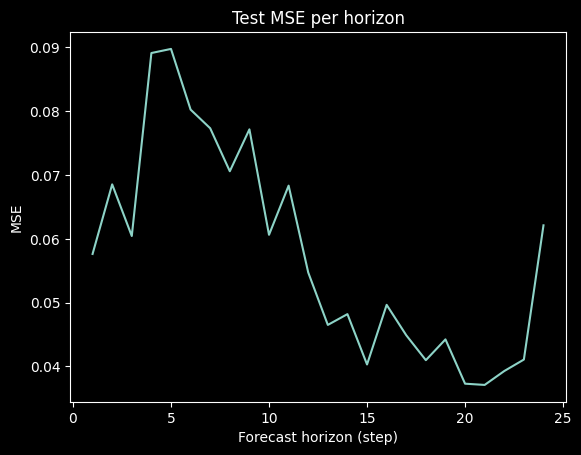

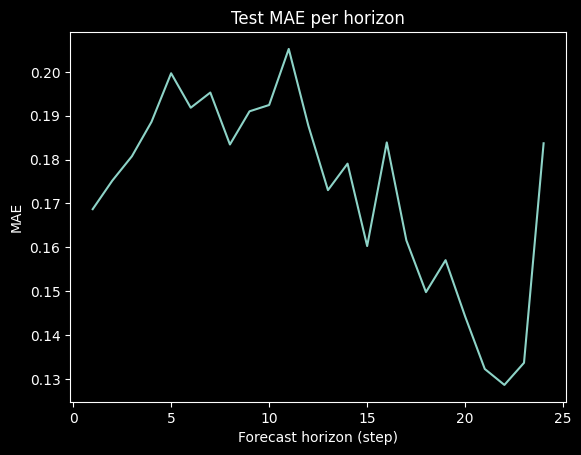

In [161]:
plt.figure()
plt.plot(np.arange(1, 25), mse_h)
plt.xlabel("Forecast horizon (step)")
plt.ylabel("MSE")
plt.title("Test MSE per horizon")
plt.show()

plt.figure()
plt.plot(np.arange(1, 25), mae_h)
plt.xlabel("Forecast horizon (step)")
plt.ylabel("MAE")
plt.title("Test MAE per horizon")
plt.show()

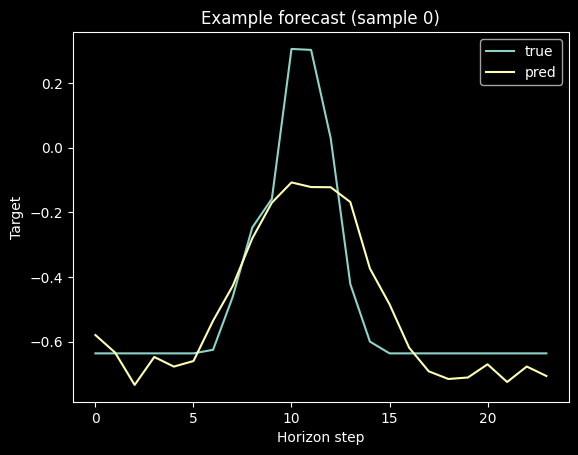

In [191]:
i = 0  # pick any sample index
plt.figure()
plt.plot(y_true[i], label="true")
plt.plot(y_pred[i], label="pred")
plt.xlabel("Horizon step")
plt.ylabel("Target")
plt.title(f"Example forecast (sample {i})")
plt.legend()
plt.show()

## Unscaled

In [240]:
from sklearn.preprocessing import StandardScaler

y_raw = df_pv["pv"].values   # <-- your real 0–400 values

train_size = int(len(y_raw) * 0.8)

y_train_raw = y_raw[:train_size]
y_test_raw  = y_raw[train_size:]

y_scaler = StandardScaler()
y_scaler.fit(y_train_raw.reshape(-1,1))

y_scaled_full = y_scaler.transform(y_raw.reshape(-1,1)).reshape(-1)

y = y_scaled_full

In [241]:
import torch
import torch.nn.functional as F
import numpy as np

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    preds = []
    trues = []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).squeeze(-1)

        pred = model(Xb)

        preds.append(pred.cpu())
        trues.append(yb.cpu())

    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(trues).numpy()

    return y_pred, y_true

In [242]:
y_pred_scaled, y_true_scaled = evaluate_model(model, test_loader, device)

In [243]:
y_true_real = y_scaler.inverse_transform(
    y_true_scaled.reshape(-1,1)
).reshape(y_true_scaled.shape)

y_pred_real = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1,1)
).reshape(y_pred_scaled.shape)

In [244]:
print("Max true:", y_true_real.max())
print("Min true:", y_true_real.min())

Max true: 94.38027
Min true: 2.8774292


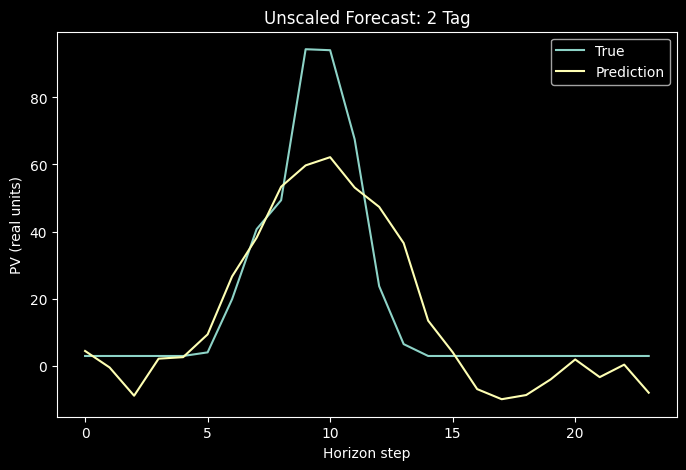

In [245]:
import matplotlib.pyplot as plt

i = 1  # sample index

plt.figure(figsize=(8,5))
plt.plot(y_true_real[i], label="True")
plt.plot(y_pred_real[i], label="Prediction")
plt.xlabel("Horizon step")
plt.ylabel("PV (real units)")
plt.title(f"Unscaled Forecast: {i+1} Tag",)
plt.legend()
plt.show()

In [246]:
mse_real = np.mean((y_pred_real - y_true_real)**2)
rmse_real = np.sqrt(mse_real)
mae_real = np.mean(np.abs(y_pred_real - y_true_real))

print("MSE (real units):", mse_real)
print("RMSE (real units):", rmse_real)
print("MAE (real units):", mae_real)

MSE (real units): 544.80225
RMSE (real units): 23.341
MAE (real units): 16.783268


# Second Traind Model

In [109]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from sklearn.model_selection import TimeSeriesSplit

# -------------------------
# Hyperparams (upgraded)
# -------------------------
BATCH_SIZE = 64
EPOCHS = 60                # allow longer training; early stopping will cut it short
LR = 1e-3
WEIGHT_DECAY = 1e-4        # important
PATIENCE = 8               # early stopping patience (epochs)

NUM_CHANNELS = [64, 64, 64, 64]  # more capacity than 32s
KERNEL_SIZE = 5                  # larger receptive field
DROPOUT = 0.1                    # often better with larger model

# Loss: Huber (robust) + horizon weighting
base_criterion = nn.SmoothL1Loss(beta=0.5, reduction="none")  # elementwise

def horizon_weighted_huber(pred, y, device):
    """
    pred,y: (B, 24)
    Weighted SmoothL1 over horizon. Slightly higher weight for later steps.
    """
    H = y.size(1)
    w = torch.linspace(1.0, 2.0, steps=H, device=device)  # (24,)
    loss_per_elem = base_criterion(pred, y)               # (B,24)
    return (loss_per_elem * w).mean()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total, n = 0.0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).squeeze(-1)  # (B,24,1)->(B,24)

        optimizer.zero_grad(set_to_none=True)
        pred = model(Xb)                # (B,24)

        loss = horizon_weighted_huber(pred, yb, device)
        loss.backward()

        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)

    return total / n

@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    total, n = 0.0, 0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).squeeze(-1)

        pred = model(Xb)
        loss = horizon_weighted_huber(pred, yb, device)

        total += loss.item() * Xb.size(0)
        n += Xb.size(0)

    return total / n

def run_timeseries_kfold(
    X_seq, y_seq,
    n_splits=5,
    device="cpu",
    save_dir="saved_models_v2",
    save_best_overall=True
):
    os.makedirs(save_dir, exist_ok=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_losses = []
    fold_paths = []

    best_overall_val = float("inf")
    best_overall_path = None

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_seq), start=1):
        train_ds = SeqDataset(X_seq[tr_idx], y_seq[tr_idx])
        val_ds   = SeqDataset(X_seq[va_idx], y_seq[va_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

        model = TCN(
            input_size=X_seq.shape[-1],  # 14
            output_size=y_seq.shape[1],  # 24
            num_channels=NUM_CHANNELS,
            kernel_size=KERNEL_SIZE,
            dropout=DROPOUT
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        # scheduler: reduce LR when val loss plateaus
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-5
        )

        best_val = float("inf")
        best_state = None
        bad_epochs = 0

        for epoch in range(1, EPOCHS + 1):
            tr_loss = train_one_epoch(model, train_loader, optimizer, device)
            va_loss = eval_one_epoch(model, val_loader, device)

            scheduler.step(va_loss)

            if va_loss < best_val - 1e-6:
                best_val = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1

            # optional print each epoch (comment out if noisy)
            # print(f"Fold {fold} | epoch {epoch:02d} | tr {tr_loss:.5f} | va {va_loss:.5f} | lr {optimizer.param_groups[0]['lr']:.2e}")

            if bad_epochs >= PATIENCE:
                break

        # restore + save best fold checkpoint
        if best_state is not None:
            model.load_state_dict(best_state)

            fold_path = os.path.join(save_dir, f"tcn_fold_{fold}.pt")
            torch.save(
                {
                    "fold": fold,
                    "best_val_loss": float(best_val),  # note: now it's weighted huber loss
                    "state_dict": best_state,
                    "hyperparams": {
                        "BATCH_SIZE": BATCH_SIZE,
                        "EPOCHS_MAX": EPOCHS,
                        "LR": LR,
                        "WEIGHT_DECAY": WEIGHT_DECAY,
                        "PATIENCE": PATIENCE,
                        "NUM_CHANNELS": NUM_CHANNELS,
                        "KERNEL_SIZE": KERNEL_SIZE,
                        "DROPOUT": DROPOUT,
                        "LOSS": "weighted SmoothL1 (Huber)",
                    },
                    "shapes": {
                        "input_size": int(X_seq.shape[-1]),
                        "output_size": int(y_seq.shape[1]),
                    }
                },
                fold_path
            )

            fold_paths.append(fold_path)

            if save_best_overall and best_val < best_overall_val:
                best_overall_val = best_val
                best_overall_path = fold_path

        fold_losses.append(float(best_val))
        print(f"Fold {fold}/{n_splits} | best val loss: {best_val:.6f}")

    if save_best_overall and best_overall_path is not None:
        best_link = os.path.join(save_dir, "tcn_best_overall_v1.pt")
        best_ckpt = torch.load(best_overall_path, map_location="cpu")
        torch.save(best_ckpt, best_link)
        print(f"Best overall model saved to: {best_link} (val loss {best_overall_val:.6f})")

    return fold_losses, fold_paths

# run
fold_losses, fold_paths = run_timeseries_kfold(
    X_train_seq, y_train_seq,
    n_splits=5,
    device=device,
    save_dir="saved_models_v2",
    save_best_overall=True
)

print("Fold losses:", fold_losses)
print("Mean ± std:", float(np.mean(fold_losses)), "±", float(np.std(fold_losses)))
print("Saved checkpoints:", fold_paths)

KeyboardInterrupt: 